In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [19]:
#loading the data
df=pd.read_csv("real_estate_price_size_year_view.csv")

In [20]:
print("=== BASIC INFO ===")
df.info()

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   100 non-null    float64
 1   size    100 non-null    float64
 2   year    100 non-null    int64  
 3   view    100 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ KB


In [21]:
df.head()

,price,size,year,view
0,234314.144,643.09,2015,No sea view
1,228581.528,656.22,2009,No sea view
2,281626.336,487.29,2018,Sea view
3,401255.608,1504.75,2015,No sea view
4,458674.256,1275.46,2009,Sea view


In [22]:
print("\n=== UNIQUE VIEWS ===")
df['view'].unique()


=== UNIQUE VIEWS ===


array(['No sea view', 'Sea view'], dtype=object)

In [23]:
print("\n=== DESCRIPTIVE STATISTICS ===")
df.describe()


=== DESCRIPTIVE STATISTICS ===


,price,size,year
count,100.000000,100.000000,100.000000
mean,292289.470160,853.024200,2012.600000
std,77051.727525,297.941951,4.729021
min,154282.128000,479.750000,2006.000000
25%,234280.148000,643.330000,2009.000000
50%,280590.716000,696.405000,2015.000000
75%,335723.696000,1029.322500,2018.000000
max,500681.128000,1842.510000,2018.000000


In [24]:
# Check correlation with price 
#Select only numeric columns for correlatio
numeric_cols=['price','size','year']
df[numeric_cols].corr()['price'].sort_values(ascending=False)

price    1.000000
size     0.862983
year     0.093014
Name: price, dtype: float64

In [25]:
#Create dummy variable for view (1 = Sea view, 0 = No sea view
df['view_sea'] = df['view'].map({'Sea view': 1, 'No sea view': 0})

<Figure size 800x600 with 0 Axes>

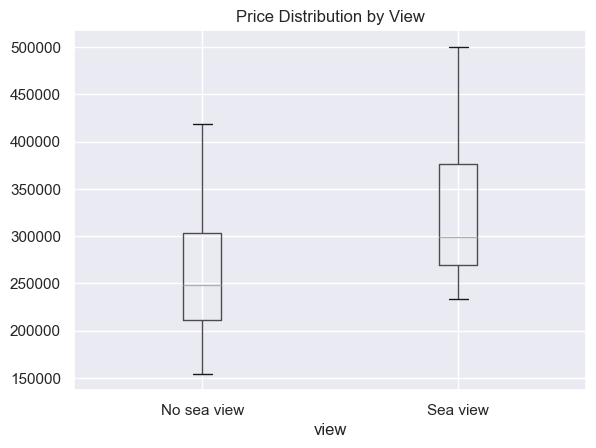

In [35]:
#Box plot - Price by View
plt.figure(figsize=(8, 6))
df.boxplot(column='price', by='view')
plt.title('Price Distribution by View')
plt.suptitle('')
plt.show()

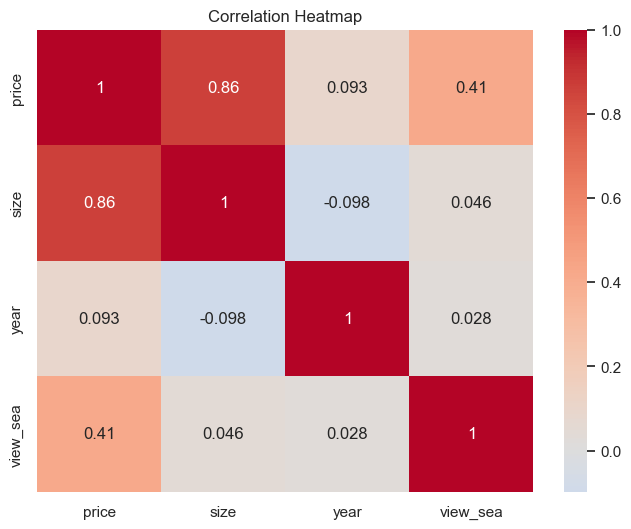

In [36]:
#Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df[['price', 'size', 'year', 'view_sea']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


In [44]:
# Prepare features and target
x=df[['size','year','view_sea']]
y=df['price']

In [45]:
# Split into training and testing
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [46]:
#train the model
model=LinearRegression()
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
# Predict on test set
y_pred=model.predict(x_test)

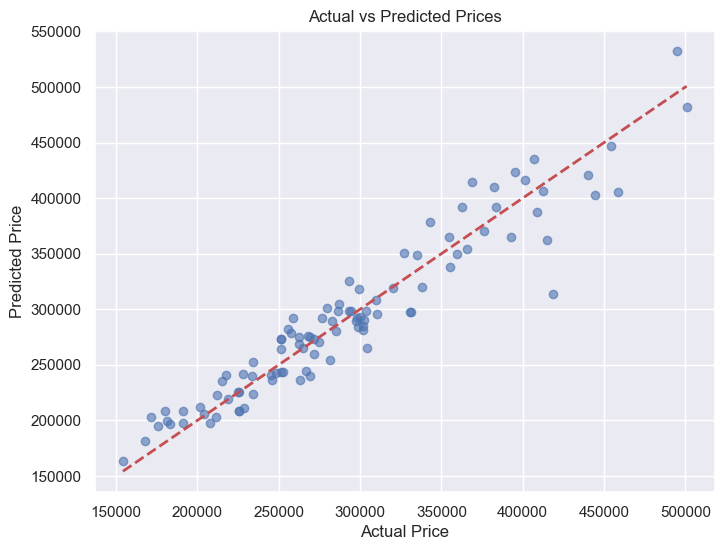

In [50]:
# Get predictions for ALL data
y_pred_all = model.predict(x)

# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_all, alpha=0.6) 
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

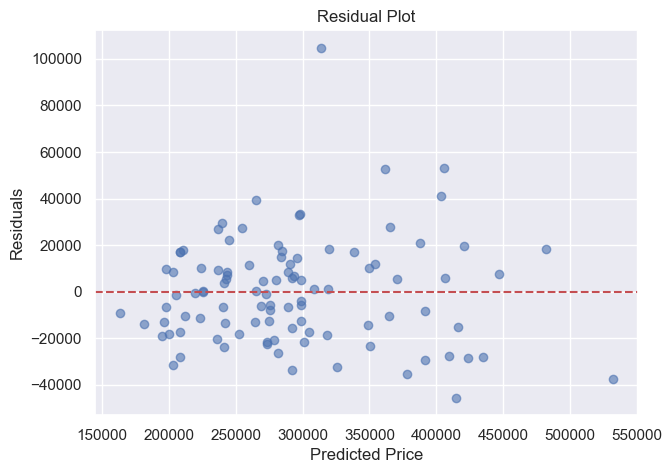

In [52]:
# Residual Plot
residuals = y - y_pred_all
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_all, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [49]:
# Results
print("=== MODEL PERFORMANCE ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"\nIntercept: ${model.intercept_:.2f}")
print("\nCoefficients:")
print(f"  Size: ${model.coef_[0]:.2f} per sq ft")
print(f"  Year: ${model.coef_[1]:.2f} per year")
print(f"  Sea view: ${model.coef_[2]:.2f}")


=== MODEL PERFORMANCE ===
R² Score: 0.9225

Intercept: $-5397914.18

Coefficients:
  Size: $223.03 per sq ft
  Year: $2718.95 per year
  Sea view: $56726.02


In [53]:
# Example: 1500 sq ft, 2015 year, with sea view
new_house = pd.DataFrame({
    'size': [1500],
    'year': [2015],
    'view_sea': [1]
})
prediction = model.predict(new_house)
print(f"Predicted price: ${prediction[0]:,.2f}")

Predicted price: $472,041.28
